# Loan Default Prediction

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn import linear_model,svm
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from ydata_profiling import ProfileReport
from summarytools import dfSummary
%matplotlib inline

In [38]:
df = pd.read_csv("../../_data/loan.csv", low_memory = False).reset_index(drop = True)

In [39]:
df.dropna(axis=1, how='all', inplace= True)

In [40]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,2500,2500,2500.0,36 months,13.56,84.92,C,C1,Chef,10+ years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,30000,30000,30000.0,60 months,18.94,777.23,D,D2,Postmaster,10+ years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,5000,5000,5000.0,36 months,17.97,180.69,D,D1,Administrative,6 years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,4000,4000,4000.0,36 months,18.94,146.51,D,D2,IT Supervisor,10+ years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,30000,30000,30000.0,60 months,16.14,731.78,C,C4,Mechanic,10+ years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 142 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    loan_amnt                                   2260668 non-null  int64  
 1    funded_amnt                                 2260668 non-null  int64  
 2    funded_amnt_inv                             2260668 non-null  float64
 3    term                                        2260668 non-null  object 
 4    int_rate                                    2260668 non-null  float64
 5    installment                                 2260668 non-null  float64
 6    grade                                       2260668 non-null  object 
 7    sub_grade                                   2260668 non-null  object 
 8    emp_title                                   2093699 non-null  object 
 9    emp_length                                  

In [43]:
profile = ProfileReport(df, title='Profiling Report')
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/jpoeder/.local/share/virtualenvs/Origination-Model-Project-LyUWVAvM/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/h1/mm91470x3ls3pm_vltf2gzn80000gn/T/ipykernel_5021/4011000574.py", line 2, in <module>
    profile.to_notebook_iframe()
  File "/Users/jpoeder/.local/share/virtualenvs/Origination-Model-Project-LyUWVAvM/lib/python3.10/site-packages/ydata_profiling/profile_report.py", line 515, in to_notebook_iframe
    display(get_notebook_iframe(self.config, self))
  File "/Users/jpoeder/.local/share/virtualenvs/Origination-Model-Project-LyUWVAvM/lib/python3.10/site-packages/ydata_profiling/report/presentation/flavours/widget/notebook.py", line 75, in get_notebook_iframe
    output = get_notebook_iframe_srcdoc(config, profile)
  File "/Users/jpoeder/.local/share/virtualenvs/Origination-Model-Project-LyUWVAvM/lib/python3.10/sit

In [ ]:
dfSummary(df, is_collapsible = True)

In [5]:
df.shape

(2260668, 145)

In [6]:
Nulldf = pd.DataFrame({'Count': df.isnull().sum(), 'Percent': 100 * df.isnull().sum()/len(df)})
Nulldf[Nulldf['Count']>0]

,Count,Percent
id,2260668,100.000000
member_id,2260668,100.000000
emp_title,166969,7.385826
emp_length,146907,6.498389
annual_inc,4,0.000177
...,...,...
settlement_status,2227612,98.537777
settlement_date,2227612,98.537777
settlement_amount,2227612,98.537777
settlement_percentage,2227612,98.537777


Dropping the variables which have more than 80% of Na Values

In [7]:
df1 = df.dropna(axis = 1, thresh = int(0.80 * len(df)))

In [8]:
df1.shape

(2260668, 87)

In [9]:
df1.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
count,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260638e+06,2.260639e+06,...,2.190392e+06,2.190392e+06,2.190237e+06,2.185289e+06,2.259303e+06,2.260563e+06,2.190392e+06,2.210638e+06,2.210638e+06,2.190392e+06
mean,1.504693e+04,1.504166e+04,1.502344e+04,1.309291e+01,4.458076e+02,7.799243e+04,1.882420e+01,3.068792e-01,5.768354e-01,1.161240e+01,...,8.293767e-02,2.076755e+00,9.411458e+01,4.243513e+01,1.281935e-01,4.677109e-02,1.782428e+05,5.102294e+04,2.319377e+04,4.373201e+04
std,9.190245e+03,9.188413e+03,9.192332e+03,4.832114e+00,2.671737e+02,1.126962e+05,1.418333e+01,8.672303e-01,8.859632e-01,5.640861e+00,...,4.935732e-01,1.830711e+00,9.036140e+00,3.621616e+01,3.646130e-01,3.775338e-01,1.815748e+05,4.991124e+04,2.300656e+04,4.507298e+04
min,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,0.000000e+00,0.000000e+00,8.000000e+00,...,0.000000e+00,1.000000e+00,9.130000e+01,0.000000e+00,0.000000e+00,0.000000e+00,5.073100e+04,2.089200e+04,8.300000e+03,1.500000e+04
50%,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,0.000000e+00,0.000000e+00,1.100000e+01,...,0.000000e+00,2.000000e+00,1.000000e+02,3.750000e+01,0.000000e+00,0.000000e+00,1.142985e+05,3.786400e+04,1.630000e+04,3.269600e+04
75%,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,0.000000e+00,1.000000e+00,1.400000e+01,...,0.000000e+00,3.000000e+00,1.000000e+02,7.140000e+01,0.000000e+00,0.000000e+00,2.577550e+05,6.435000e+04,3.030000e+04,5.880425e+04
max,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,3.300000e+01,1.010000e+02,...,5.800000e+01,3.200000e+01,1.000000e+02,1.000000e+02,1.200000e+01,8.500000e+01,9.999999e+06,3.408095e+06,1.569000e+06,2.118996e+06


## Target Column

In [10]:
df1.loan_status.value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

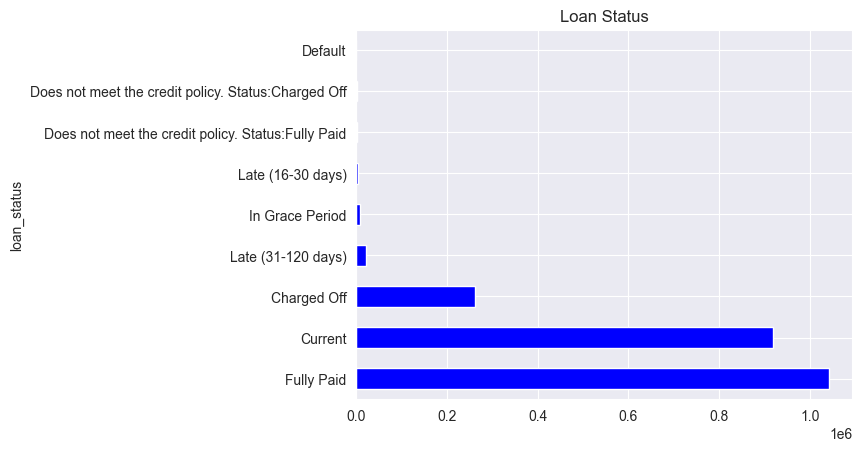

In [11]:
df1['loan_status'].value_counts().plot(kind= 'barh',color = 'blue', title = 'Loan Status')
plt.show()

In [12]:
loan_data = df1[(df1['loan_status'] == "Fully Paid") | (df1['loan_status'] == "Charged Off")]

In [13]:
loan_data.shape

(1303607, 87)

In [14]:
loan_data.loan_status = loan_data.loan_status.astype('category').cat.codes

/var/folders/h1/mm91470x3ls3pm_vltf2gzn80000gn/T/ipykernel_53482/2807948574.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data.loan_status = loan_data.loan_status.astype('category').cat.codes


In [15]:
loan_data.loan_status.value_counts()

loan_status
1    1041952
0     261655
Name: count, dtype: int64

## Data Processing and Data Cleaning

### id  and member_id
We can remove id and member_id as they will be of no use in prediction of loan status.

### loan_amnt : 
The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.

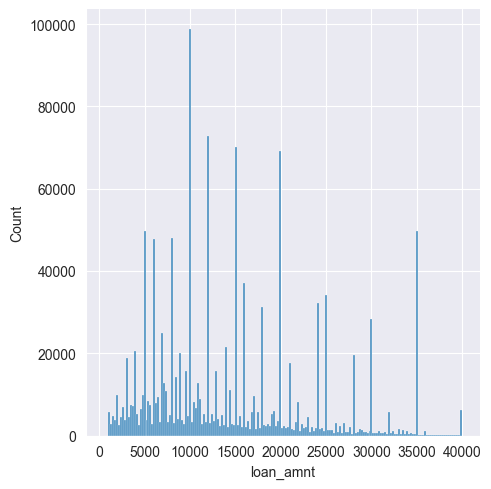

In [16]:
sns.displot(loan_data["loan_amnt"])

### funded_amnt and funded_amnt_inv
funded_amnt: The total amount committed to that loan at that point in time. 
funded_amnt_inv: The total amount committed by investors for that loan at that point in time.

In [17]:
loan_data.funded_amnt.describe()

count    1.303607e+06
mean     1.440812e+04
std      8.695472e+03
min      5.000000e+02
25%      8.000000e+03
50%      1.200000e+04
75%      2.000000e+04
max      4.000000e+04
Name: funded_amnt, dtype: float64

In [18]:
loan_data.funded_amnt_inv.describe()

count    1.303607e+06
mean     1.438520e+04
std      8.697984e+03
min      0.000000e+00
25%      7.900000e+03
50%      1.200000e+04
75%      2.000000e+04
max      4.000000e+04
Name: funded_amnt_inv, dtype: float64

In [19]:
np.corrcoef(loan_data.funded_amnt, loan_data.funded_amnt_inv)

array([[1.        , 0.99906273],
       [0.99906273, 1.        ]])

In [20]:
np.corrcoef(loan_data.funded_amnt_inv, loan_data.loan_amnt)

array([[1.        , 0.99851549],
       [0.99851549, 1.        ]])

In [21]:
loan_data[['funded_amnt','funded_amnt_inv','loan_amnt']].head()

,funded_amnt,funded_amnt_inv,loan_amnt
100,30000,30000.0,30000
152,40000,40000.0,40000
170,20000,20000.0,20000
186,4500,4500.0,4500
215,8425,8425.0,8425


Since, both funded_amnt and funded_amnt_inv are correlated with loan amount we will have to drop them. 

In [22]:
loan_data = loan_data.drop(["funded_amnt", "funded_amnt_inv"], axis=1)

### int_rate, grade and sub grade

<Axes: xlabel='grade', ylabel='int_rate'>

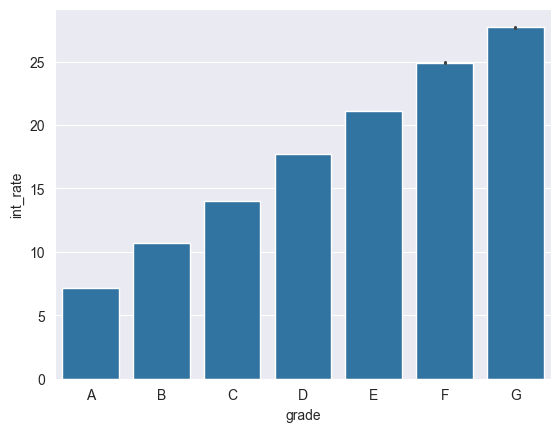

In [23]:
sns.barplot(x="grade", y="int_rate", data = loan_data, order= ["A","B","C","D","E","F","G"])

<Axes: xlabel='sub_grade', ylabel='int_rate'>

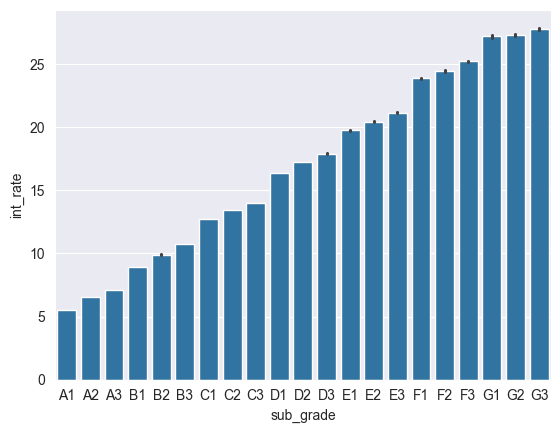

In [24]:
sns.barplot(x="sub_grade", y="int_rate" ,data = loan_data,order= ["A1","A2","A3","B1","B2","B3","C1","C2","C3","D1","D2","D3","E1","E2","E3","F1","F2","F3","G1","G2","G3",])

As we can see grade and sub-grade are given based on the int_rate so we can drop both of these variables.

In [25]:
loan_data = loan_data.drop(["grade","sub_grade"], axis = 1)

### emp_title
The job title supplied by the Borrower when applying for the loan.

In [26]:
loan_data.emp_title.value_counts()

emp_title
Teacher                             20496
Manager                             18704
Owner                                9803
Registered Nurse                     8477
RN                                   8253
                                    ...  
Branch Retail Executive, Manager        1
tile cutting                            1
Global Payroll                          1
Snack Bar Attendant                     1
Acft mechanic                           1
Name: count, Length: 371435, dtype: int64

In [27]:
loan_data.emp_title.isna().sum()

82579

emp_title feature will be very hard to evaluate and it also has many NA values. So, dropping this feature for the sake of simplicity

In [28]:
loan_data = loan_data.drop("emp_title", axis= 1)

### zip_code
The first 3 numbers of the zip code provided by the borrower in the loan application.
The first 3 numbers do not tell us and we also have the state address in which a person lives. So, dropping this.

In [29]:
loan_data = loan_data.drop("zip_code", axis= 1)

### issue_d
When the loan was funded do not add value in our analysis. Also, it is a time series data and it will expand our model. So, better to remove it.

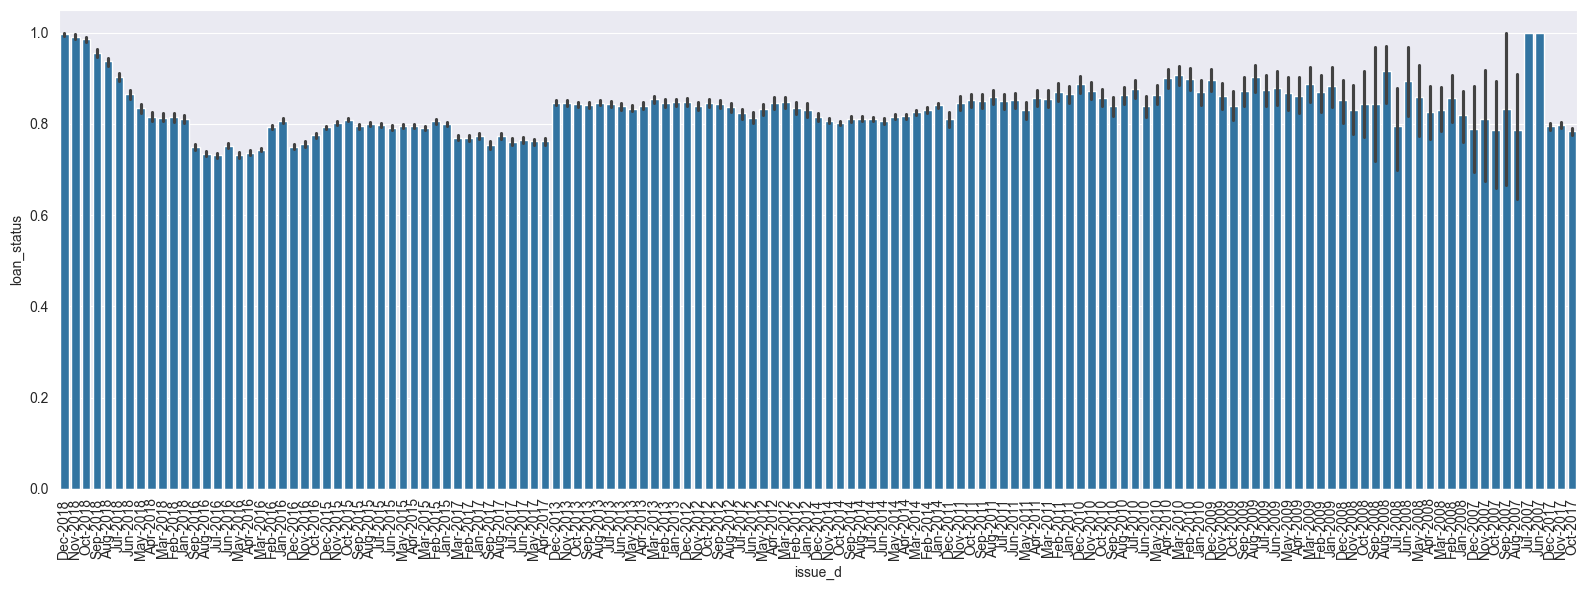

In [30]:
plt.figure(figsize=(16,6))
sns.barplot(x="issue_d", y="loan_status", data=loan_data)
plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

In [31]:
loan_data = loan_data.drop("issue_d", axis= 1)

### out_prncp, out_prncp_inv
Both of this are related to remaining outstanding principal. It is about the future so they are of no use.  

In [32]:
loan_data = loan_data.drop(["out_prncp","out_prncp_inv"], axis = 1)

### total_pymnt, total_pymnt_inv, total_rec_prncp
- total_pymnt: Payments received to date for total amount funded
- total_pymnt_inv: Payments received to date for portion of total amount funded by investors
- total_rec_prncp: Principal received to date

In [33]:
np.corrcoef(loan_data.total_pymnt, loan_data.total_pymnt_inv)

array([[1.        , 0.99926779],
       [0.99926779, 1.        ]])

In [34]:
np.corrcoef(loan_data.total_pymnt, loan_data.total_rec_prncp)


array([[1.        , 0.96746463],
       [0.96746463, 1.        ]])

removing total_payment_inv and total_rec_prncp

In [35]:
loan_data = loan_data.drop(["total_pymnt_inv","total_rec_prncp"], axis = 1)

### total_rec_late_fee
Late fees received to date
This is considered in total payment and does not add value in our analysis so removing it.

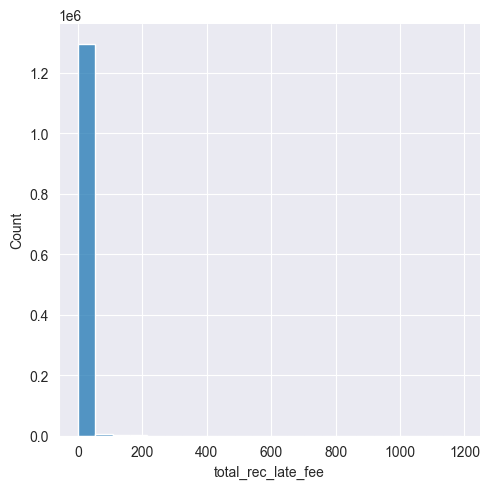

In [36]:
sns.displot(loan_data.total_rec_late_fee)

In [37]:
loan_data = loan_data.drop("total_rec_late_fee", axis = 1)

### total_rec_int
Interest received to date
This is dependent on the loan duration and interest of the loan. So, droppig this to make model simpler.

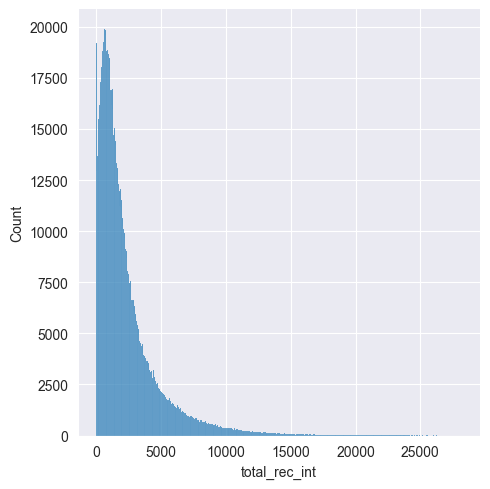

In [38]:
sns.displot(loan_data.total_rec_int)

In [39]:
loan_data = loan_data.drop("total_rec_int", axis = 1)

### recoveries, collection_recovery_fee, last_pymnt_d, last_pymnt_amnt
- recoveries, collection_recovery_fee,last_pymnt_amnt: These variables are not useful as they are included in total amount paid. 
- last_pymnt_d is not useful as it does not help predict the future status of the loan.

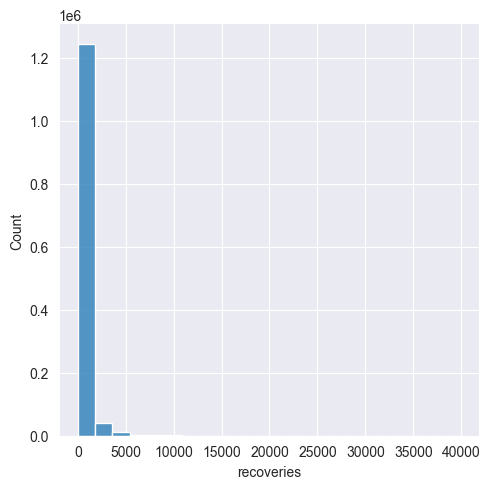

In [40]:
sns.displot(loan_data.recoveries)

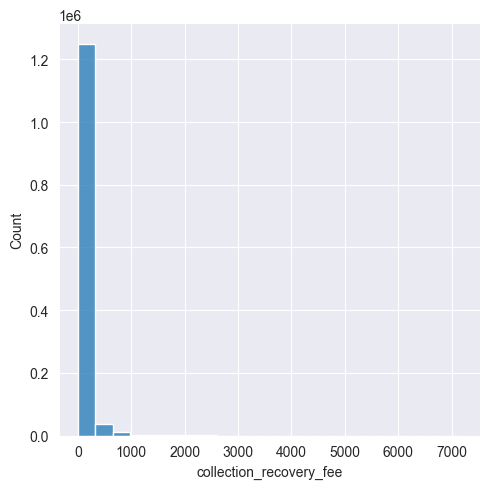

In [41]:
sns.displot(loan_data.collection_recovery_fee)

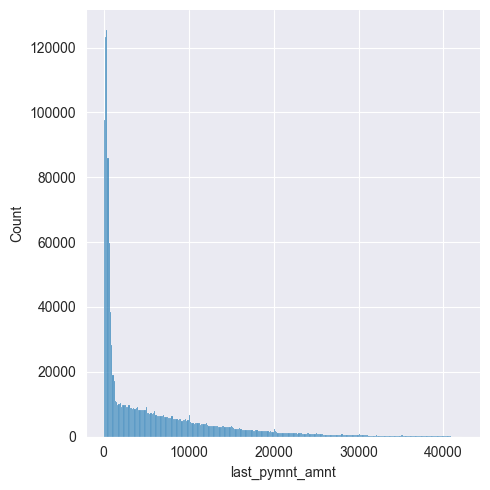

In [42]:
sns.displot(loan_data.last_pymnt_amnt)

In [43]:
loan_data = loan_data.drop(['recoveries', 'collection_recovery_fee', 
                              'last_pymnt_d', 'last_pymnt_amnt'], axis =1)

In [44]:
loan_data.shape

(1303607, 70)

In [45]:
loan_data.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'loan_status',
       'pymnt_plan', 'purpose', 'title', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'total_pymnt', 'last_credit_pull_d', 'collections_12_mths_ex_med',
       'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths',
       'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths',
       'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
       'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
       'mths_since_recent_bc', 'mths_since_recent_inq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 

### url
we do not need url

### policy_code, application_type, pymnt_plan

In [46]:
loan_data.policy_code.value_counts()

policy_code
1    1303607
Name: count, dtype: int64

In [47]:
loan_data.application_type.value_counts()

application_type
Individual    1280370
Joint App       23237
Name: count, dtype: int64

In [48]:
loan_data.pymnt_plan.value_counts()

pymnt_plan
n    1303607
Name: count, dtype: int64

In [49]:
loan_data.shape[0]

1303607

Since, all the values are in only one category, they will not help us.

In [50]:
loan_data = loan_data.drop(["policy_code", "application_type", "pymnt_plan"], axis = 1)

### initial_list_status

In [51]:
loan_data.initial_list_status.value_counts()

initial_list_status
w    751214
f    552393
Name: count, dtype: int64

<Axes: xlabel='initial_list_status', ylabel='loan_status'>

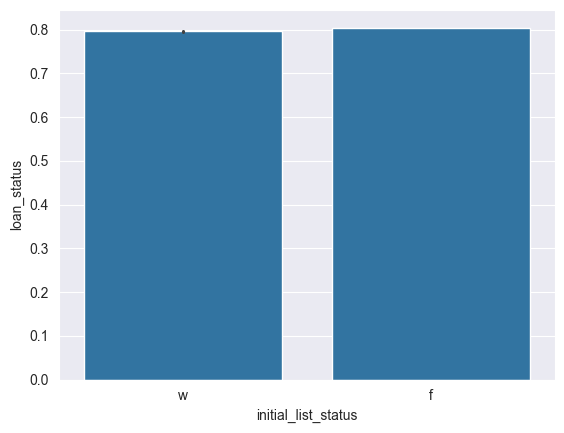

In [52]:
sns.barplot(x="initial_list_status", y="loan_status", data = loan_data)

As we can see, initial list status does not matter whether it is a whole or fractional. So, removing it.

In [53]:
loan_data = loan_data.drop("initial_list_status", axis = 1)

### last_credit_pull_d
Will have to remove it as it will expand our model 

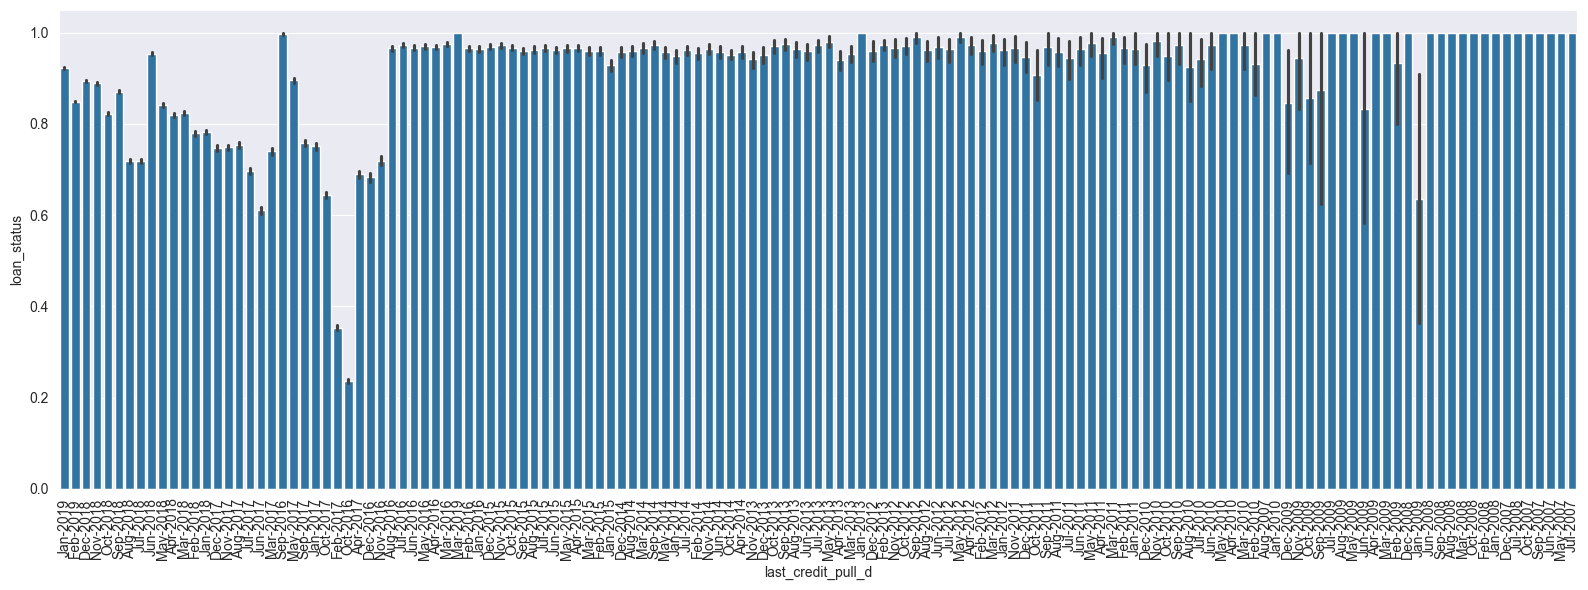

In [54]:
plt.figure(figsize=(16,6))
sns.barplot(x="last_credit_pull_d", y="loan_status", data=loan_data)
plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

In [55]:
loan_data = loan_data.drop("last_credit_pull_d", axis = 1)

### collections_12_mths_ex_med

In [56]:
loan_data.collections_12_mths_ex_med.value_counts()

collections_12_mths_ex_med
0.0     1283341
1.0       18728
2.0        1242
3.0         150
4.0          51
5.0          16
6.0           9
7.0           4
10.0          2
12.0          2
9.0           2
8.0           1
14.0          1
16.0          1
20.0          1
Name: count, dtype: int64

removing it as most of the values are 0.

In [57]:
loan_data = loan_data.drop("collections_12_mths_ex_med", axis = 1)

### purpose and title

In [58]:
loan_data.purpose.value_counts()

purpose
debt_consolidation    757591
credit_card           285704
home_improvement       84495
other                  74934
major_purchase         28328
medical                15023
small_business         15010
car                    14120
moving                  9172
vacation                8732
house                   6967
wedding                 2294
renewable_energy         911
educational              326
Name: count, dtype: int64

In [59]:
loan_data.title.head(10)

100         Debt consolidation
152    Credit card refinancing
170    Credit card refinancing
186    Credit card refinancing
215    Credit card refinancing
269         Debt consolidation
271    Credit card refinancing
296                      Other
369                Home buying
379    Credit card refinancing
Name: title, dtype: object

In [60]:
loan_data[["purpose","title"]].head(10)

,purpose,title
100,debt_consolidation,Debt consolidation
152,credit_card,Credit card refinancing
170,credit_card,Credit card refinancing
186,credit_card,Credit card refinancing
215,credit_card,Credit card refinancing
269,debt_consolidation,Debt consolidation
271,credit_card,Credit card refinancing
296,other,Other
369,house,Home buying
379,credit_card,Credit card refinancing


As we can see, purpose and title are similar and title seems to be an explanation. Purpose has all types of categories so let's drop title.

In [61]:
loan_data = loan_data.drop("title", axis =1)

### addr_state

In [62]:
loan_data.addr_state.value_counts()

addr_state
CA    191032
TX    106673
NY    106384
FL     92619
IL     50027
NJ     46884
PA     44117
OH     42436
GA     42031
VA     36852
NC     36615
MI     34128
AZ     31716
MD     30222
MA     30007
CO     28858
WA     28361
MN     23241
IN     21018
MO     20563
TN     19666
NV     19652
CT     19063
WI     17137
AL     16129
OR     15965
SC     15477
LA     15021
KY     12438
OK     11846
KS     10892
UT      9785
AR      9708
NM      7158
HI      6568
MS      6316
NH      6243
RI      5692
WV      4745
MT      3699
DE      3666
NE      3422
DC      3370
AK      3097
WY      2835
SD      2679
VT      2559
ME      1920
ID      1557
ND      1511
IA         7
Name: count, dtype: int64

As, there are somany categories we will have to drop this feature as it will increase variables if we encode them.

In [63]:
loan_data = loan_data.drop("addr_state", axis = 1)

### acc_now_delinq

In [64]:
loan_data.acc_now_delinq.value_counts()

acc_now_delinq
0.0     1297441
1.0        5809
2.0         301
3.0          41
4.0          10
5.0           3
6.0           1
14.0          1
Name: count, dtype: int64

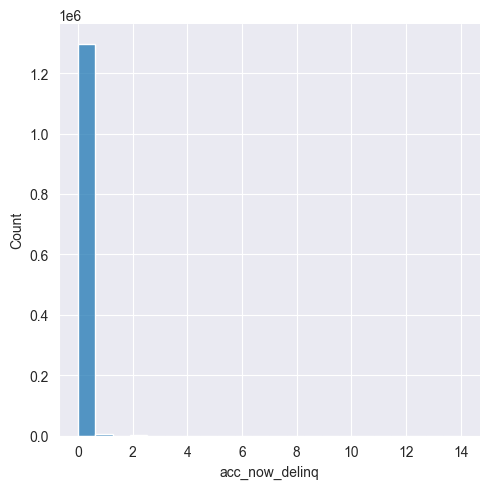

In [65]:
sns.displot(loan_data.acc_now_delinq)

Removing it as most of the values are 0

In [66]:
loan_data= loan_data.drop("acc_now_delinq", axis=1)

### tot_cur_bal
Total current balance of all accounts

In [67]:
loan_data.tot_cur_bal.isna().sum()

67527

In [68]:
loan_data.tot_cur_bal.median()

80334.5

In [69]:
loan_data.tot_cur_bal.mean()

141079.67888809787

There is a big difference between mean and median so, we cannot impute and dropping it would be the best choice.

In [70]:
loan_data = loan_data.drop("tot_cur_bal", axis = 1 )

### tot_coll_amt
Total collection amounts ever owed

In [71]:
loan_data.tot_coll_amt.isna().sum()

67527

In [72]:
loan_data.tot_coll_amt.value_counts().head()/loan_data.shape[0]

tot_coll_amt
0.0      0.803126
50.0     0.001905
100.0    0.001566
75.0     0.001168
150.0    0.000868
Name: count, dtype: float64

Most of the values are 0 and there are many values not availabe. we should drop this feature.

In [73]:
loan_data = loan_data.drop("tot_coll_amt", axis = 1 )

### total_rev_hi_lim
Total revolving high credit/credit limit

In [74]:
loan_data.total_rev_hi_lim.isna().sum()

67527

In [75]:
loan_data.total_rev_hi_lim.mean()

32708.15704323345

In [76]:
loan_data.total_rev_hi_lim.median()

24000.0

In [77]:
loan_data.total_rev_hi_lim.fillna(loan_data.total_rev_hi_lim.median(), inplace=True)

In [78]:
loan_data.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'loan_status',
       'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'total_pymnt', 'total_rev_hi_lim', 'acc_open_past_24mths',
       'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths',
       'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
       'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
       'mths_since_recent_bc', 'mths_since_recent_inq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
       'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
       'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
       'tax_liens', 'tot_h

In [79]:
loan_data.shape

(1303607, 59)

## Numerical features

In [80]:
num_cols = loan_data._get_numeric_data().columns
data = loan_data[num_cols]

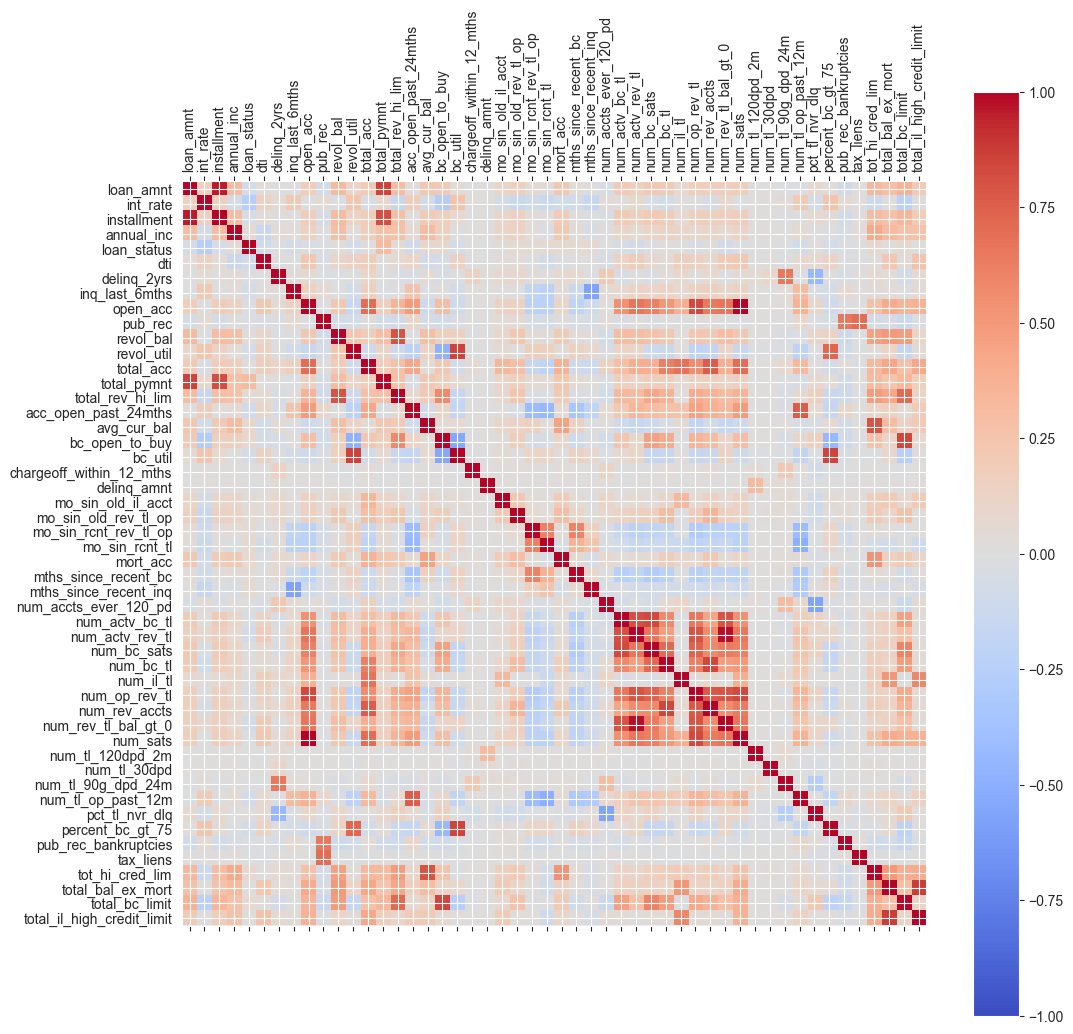

In [81]:
corr = data[num_cols].corr()
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111)
cax = ax.matshow(corr,cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0,len(data.columns),1)
ax.set_xticks(ticks)
plt.xticks(rotation=90)
ax.set_yticks(ticks)
ax.set_xticklabels(data.columns)
ax.set_yticklabels(data.columns)
plt.show()

All features are important and we cannot drop any of them.

## Categorical features

In [82]:
loan_data.columns[loan_data.dtypes == object]

Index(['term', 'emp_length', 'home_ownership', 'verification_status',
       'purpose', 'earliest_cr_line', 'hardship_flag', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object')

### term

<Axes: xlabel='term', ylabel='loan_status'>

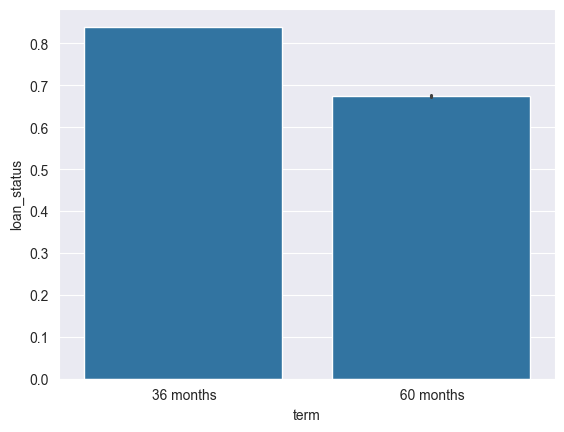

In [83]:
sns.barplot(x = "term", y = "loan_status", data = loan_data)

### emp_length              

In [84]:
loan_data.emp_length.value_counts()

emp_length
10+ years    428547
2 years      117820
< 1 year     104550
3 years      104200
1 year        85677
5 years       81623
4 years       78029
6 years       60933
8 years       59125
7 years       58145
9 years       49504
Name: count, dtype: int64

In [85]:
loan_data.emp_length.isna().sum()

75454

In [86]:
loan_data["emp_length"] = loan_data["emp_length"].replace({'years':'','year':'',' ':'','<':'','\+':'','n/a':'0'}, regex = True)

In [87]:
loan_data.emp_length.isna().sum()

75454

In [88]:
loan_data.fillna(0, inplace=True)

In [89]:
loan_data["emp_length"] = loan_data["emp_length"].apply(lambda x:int(x))

<Axes: xlabel='emp_length', ylabel='loan_status'>

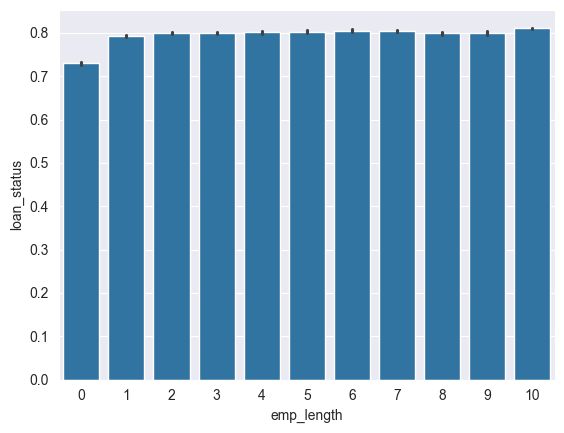

In [90]:
sns.barplot(x = "emp_length", y = "loan_status", data = loan_data)

### home_ownership          

In [91]:
loan_data.home_ownership.value_counts()

home_ownership
MORTGAGE    645496
RENT        517808
OWN         139844
ANY            267
OTHER          144
NONE            48
Name: count, dtype: int64

<Axes: xlabel='home_ownership', ylabel='loan_status'>

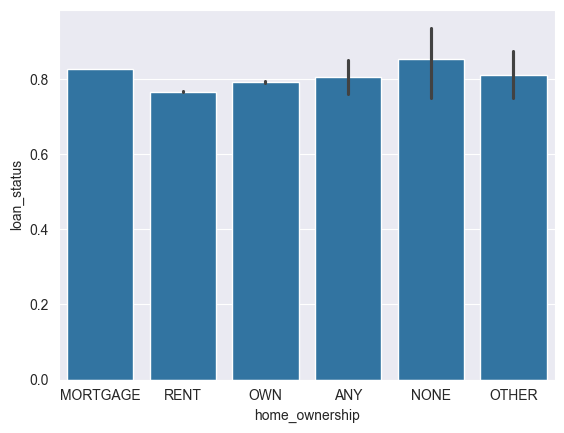

In [92]:
sns.barplot(x = "home_ownership", y = "loan_status", data = loan_data)

### verification_status

In [93]:
loan_data.verification_status.value_counts()

verification_status
Source Verified    503726
Verified           407676
Not Verified       392205
Name: count, dtype: int64

<Axes: xlabel='verification_status', ylabel='loan_status'>

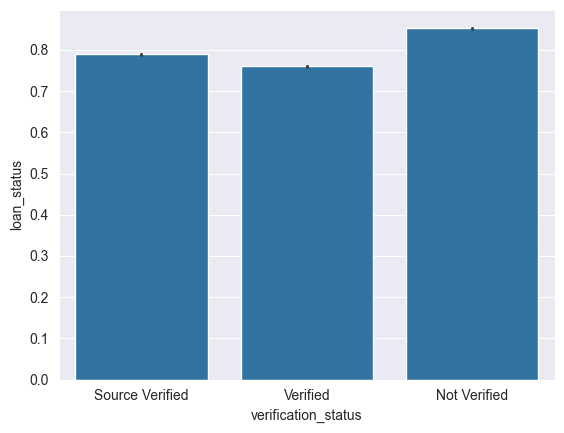

In [94]:
sns.barplot(x = "verification_status", y = "loan_status", data = loan_data)

### purpose

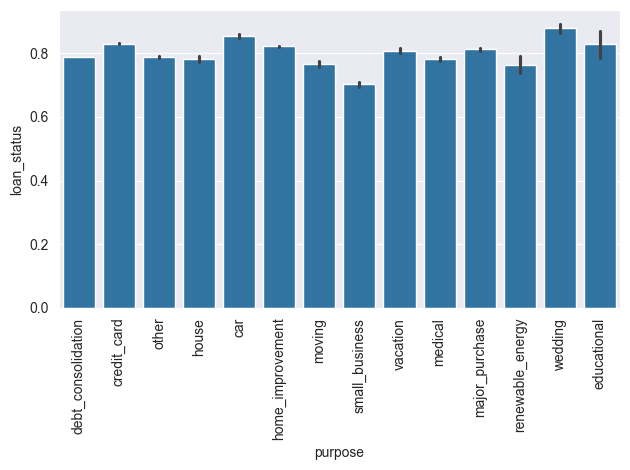

In [95]:
sns.barplot(x="purpose", y="loan_status", data=loan_data)
plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

### earliest_cr_line
"The month the borrower's earliest reported credit line was opened"

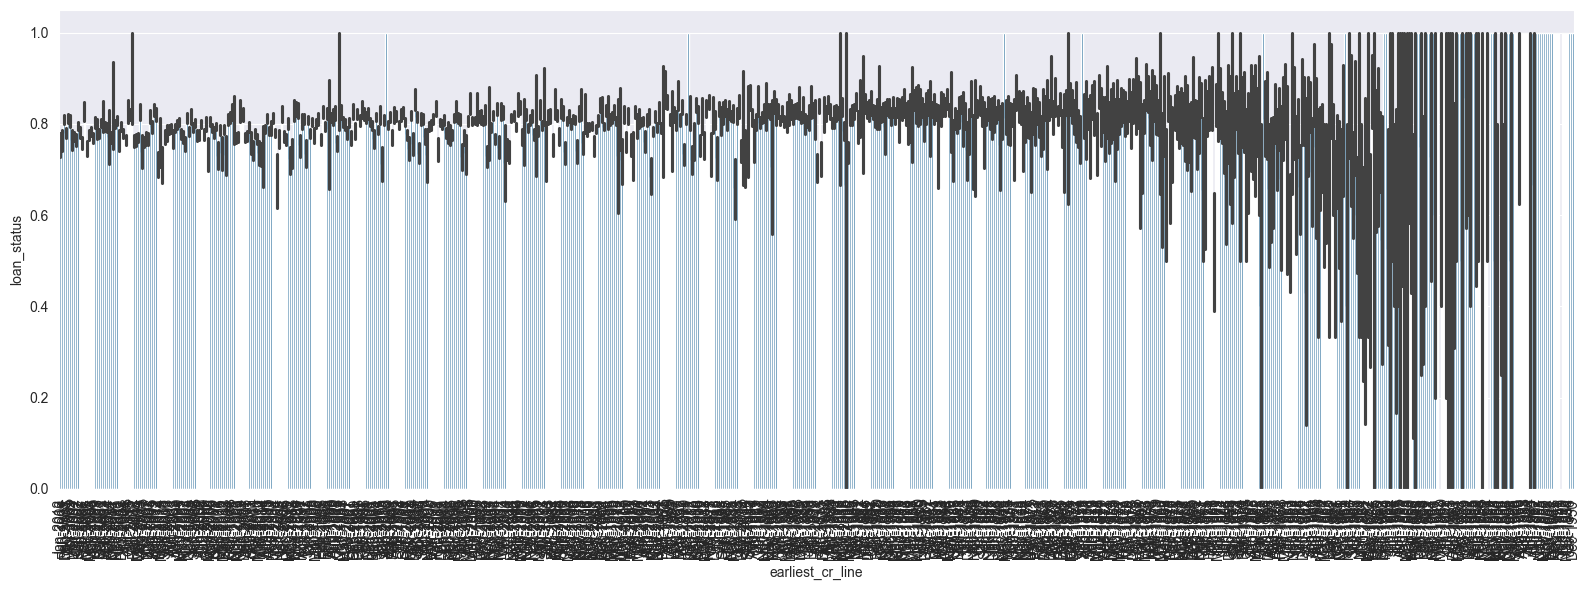

In [96]:
plt.figure(figsize=(16,6))
sns.barplot(x = "earliest_cr_line", y = "loan_status", data = loan_data)
plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

We will have to remove this fetaure as it will increase the complexity of our model.

In [97]:
loan_data = loan_data.drop("earliest_cr_line", axis = 1)

### Encoding 

In [98]:
categorical = ['term', 'home_ownership', 'verification_status', 'purpose']

In [99]:
loan_data = pd.get_dummies(loan_data, columns = categorical)

In [100]:
loan_data.dtypes

loan_amnt                     int64
int_rate                    float64
installment                 float64
emp_length                    int64
annual_inc                  float64
                             ...   
purpose_other                  bool
purpose_renewable_energy       bool
purpose_small_business         bool
purpose_vacation               bool
purpose_wedding                bool
Length: 79, dtype: object

In [101]:
loan_data.isna().sum()

loan_amnt                   0
int_rate                    0
installment                 0
emp_length                  0
annual_inc                  0
                           ..
purpose_other               0
purpose_renewable_energy    0
purpose_small_business      0
purpose_vacation            0
purpose_wedding             0
Length: 79, dtype: int64

## Train-Test Split

In [102]:
Y = loan_data.loan_status
X = loan_data.drop("loan_status", axis = 1)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, stratify = Y )

In [103]:
print("Shape of x_train: ", x_train.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of x_test: ", x_test.shape)
print("Shape of y_test: ", y_test.shape)

Shape of x_train:  (1042885, 78)
Shape of y_train:  (1042885,)
Shape of x_test:  (260722, 78)
Shape of y_test:  (260722,)


## Models

In [104]:
def print_score(clf, X_train, y_train, X_test, y_test, train=True):
    if train:
        print("Train Result:\n")
        print("accuracy score: {0:.4f}\n".format(accuracy_score(y_train, clf.predict(X_train))))
        print("Classification Report: \n {}\n".format(classification_report(y_train, clf.predict(X_train))))
        print("Confusion Matrix: \n {}\n".format(confusion_matrix(y_train, clf.predict(X_train))))

        res = cross_val_score(clf, X_train, y_train, cv=10, scoring='accuracy')
        print("Average Accuracy: \t {0:.4f}".format(np.mean(res)))
        print("Accuracy SD: \t\t {0:.4f}".format(np.std(res)))
        
    elif train==False:
        print("Test Result:\n")        
        print("accuracy score: {0:.4f}\n".format(accuracy_score(y_test, clf.predict(X_test))))
        print("Classification Report: \n {}\n".format(classification_report(y_test, clf.predict(X_test))))
        print("Confusion Matrix: \n {}\n".format(confusion_matrix(y_test, clf.predict(X_test))))    

### Over Sampling Using SMOTE

In [105]:
data_type_dict = x_train.dtypes
cat_vars = []
for key, value in data_type_dict.items():
    if data_type_dict[key] in ['bool', 'object']:
        cat_vars.append(key)
print(cat_vars)

['hardship_flag', 'disbursement_method', 'debt_settlement_flag', 'term_ 36 months', 'term_ 60 months', 'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Not Verified', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding']


In [106]:
#sm = SMOTENC(random_state=12, categorical_features=cat_vars)
#x_train_r, y_train_r = sm.fit_resample(x_train, y_train)

### Logistic Regression

In [108]:
log_reg = LogisticRegression(C = 0.0001,random_state=21)

#log_reg.fit(x_train_r, y_train_r)
x_train.drop(cat_vars, axis=1, inplace=True)
log_reg.fit(x_train, y_train)

/Users/jpoeder/.local/share/virtualenvs/Origination-Model-Project-LyUWVAvM/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=0.0001, random_state=21)

In [109]:
#print_score(log_reg, x_train_r, y_train_r, x_test, y_test, train=False)
print_score(log_reg, x_train, y_train, x_test, y_test, train=False)

Test Result:


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- debt_settlement_flag
- disbursement_method
- hardship_flag
- home_ownership_ANY
- home_ownership_MORTGAGE
- ...


In [ ]:
cm = confusion_matrix(y_test, log_reg.predict(x_test)).T
cm = cm.astype('float')/cm.sum(axis=0)

ax = sns.heatmap(cm, annot=True, cmap='Blues');
ax.set_xlabel('True Value')
ax.set_ylabel('Predicted Value')
ax.axis('equal')

### Random Forest

In [110]:
clf_rf = RandomForestClassifier(n_estimators=10, random_state=21)
#clf_rf.fit(x_train_r, y_train_r)
clf_rf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=21)

In [ ]:
#print_score(clf_rf, x_train_r, y_train_r, x_test, y_test, train=False)
print_score(clf_rf, x_train, y_train, x_test, y_test, train=False)

In [ ]:
cm = confusion_matrix(y_test, clf_rf.predict(x_test)).T
cm = cm.astype('float')/cm.sum(axis=0)

ax = sns.heatmap(cm, annot=True, cmap='Blues');
ax.set_xlabel('True Value')
ax.set_ylabel('Predicted Value')
ax.axis('equal')

In [ ]:
len(loan_data.columns)

In [ ]:
fig, ax = plt.subplots(figsize=(8,15))
width=0.55
ax.barh(np.arange(40), RandomForestClassifier.feature_importances_, width)
ax.set_yticks(np.arange(len(RandomForestClassifier.feature_importances_)))
ax.set_yticklabels(x_train.columns.values)
plt.title('Feature Importance from DT')
ax.set_ylabel('Normalized Gini Importance')


### LightGBM

In [ ]:
def kfold_lightgbm(train_df, num_folds, stratified = False):
    print("Starting LightGBM. Train shape: {}".format(train_df.shape))
    
    # Cross validation model
    if stratified:
        folds = StratifiedKFold(n_splits= num_folds, shuffle=True, random_state=47)
    else:
        folds = KFold(n_splits= num_folds, shuffle=True, random_state=47)

    oof_preds = np.zeros(train_df.shape[0])

    feature_importance_df = pd.DataFrame()
    feats = [f for f in train_df.columns if f not in ['loan_status']]
    
    # Splitting the training set into folds for Cross Validation
    for n_fold, (train_idx, valid_idx) in enumerate(folds.split(train_df[feats], train_df['loan_status'])):
        train_x, train_y = train_df[feats].iloc[train_idx], train_df['loan_status'].iloc[train_idx]
        valid_x, valid_y = train_df[feats].iloc[valid_idx], train_df['loan_status'].iloc[valid_idx]

        # LightGBM parameters found by Bayesian optimization
        clf = LGBMClassifier(
            nthread=4,
            n_estimators=10000,
            learning_rate=0.02,
            num_leaves=32,
            colsample_bytree=0.9497036,
            subsample=0.8715623,
            max_depth=8,
            reg_alpha=0.04,
            reg_lambda=0.073,
            min_split_gain=0.0222415,
            min_child_weight=40,
            silent=-1,
            verbose=-1,
            )

        # Fitting the model and evaluating by AUC
        clf.fit(train_x, train_y, eval_set=[(train_x, train_y), (valid_x, valid_y)], 
            eval_metric= 'auc', verbose= 1000, early_stopping_rounds= 200)
        print_score(clf, train_x, train_y, valid_x, valid_y, train=False)
        # Dataframe holding the different features and their importance
        fold_importance_df = pd.DataFrame()
        fold_importance_df["feature"] = feats
        fold_importance_df["importance"] = clf.feature_importances_
        fold_importance_df["fold"] = n_fold + 1
        feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis=0)

    display_importances(feature_importance_df)
    return feature_importance_df

In [ ]:
def display_importances(feature_importance_df_):
    cols = feature_importance_df_[["feature", "importance"]].groupby("feature").mean().sort_values(by="importance", ascending=False)[:40].index
    best_features = feature_importance_df_.loc[feature_importance_df_.feature.isin(cols)]
    plt.figure(figsize=(15, 12))
    sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
    plt.title('LightGBM Features (avg over folds)')
    plt.tight_layout()
    plt.savefig('lgbm_importances.png')

In [ ]:
feat_importance = kfold_lightgbm(loan_data, num_folds= 3, stratified= False)